## Reglas de asociación - Análisis

Se interpretan las reglas generadas en `c_reglas.ipynb`

### Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
reglas_dir = proyecto / "05_Asociacion" / "temp" / "c_reglas"
out_dir = proyecto / "05_Asociacion" / "temp" / "d_analisis"
fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
for d in (fig_dir, tab_dir, web_dir):
    d.mkdir(parents=True, exist_ok=True)

spark = SparkSession.builder.appName("asociacion-analisis").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.max_colwidth", 80)

def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre):
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()

### 1. Carga de reglas

In [3]:
assert (reglas_dir / "fpg_full").exists(), "Corre c_reglas.ipynb (Run All) antes que este notebook."

reglas_fpg_full = spark.read.parquet(str(reglas_dir / "fpg_full")).toPandas()
reglas_apriori_q4 = spark.read.parquet(str(reglas_dir / "apriori_q4")).toPandas()

print(f"Reglas disponibles (completo): {len(reglas_fpg_full):,} | (Apriori, Q4): {len(reglas_apriori_q4):,}")

Reglas disponibles (completo): 496 | (Apriori, Q4): 583


### 2. Reglas relevantes

- Se separan las 496 reglas en dos grupos: `reglas_p1` (36, con `comp=postor_unico`) y `reglas_otras` (460, el resto)

- Cada grupo se ordena por `lift` descendente

- Se toman las top 7 de `reglas_p1` + las top 7 de `reglas_otras` = 14 reglas

- Se marca cuáles también aparecen en el subconjunto Apriori-Q4 (`estable_en_q4`)

In [4]:
def involucra_postor_unico(items):
    return "comp=postor_unico" in items

es_p1 = reglas_fpg_full["antecedente"].apply(involucra_postor_unico) | reglas_fpg_full["consecuente"].apply(involucra_postor_unico)

reglas_p1 = reglas_fpg_full[es_p1].sort_values("lift", ascending=False)
reglas_otras = reglas_fpg_full[~es_p1].sort_values("lift", ascending=False)

print(f"Reglas relacionadas con postor_unico: {len(reglas_p1):,} | otras: {len(reglas_otras):,}")
reglas_p1.head(10)

Reglas relacionadas con postor_unico: 36 | otras: 460


,antecedente,consecuente,soporte,confianza,lift,interes,redundante
23,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.022954,0.530980,9.121065,0.472766,False
297,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.028628,0.693888,8.814776,0.615169,False
365,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.023729,0.689193,8.755127,0.610474,False
22,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.022954,0.935891,8.371007,0.824089,False
27,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025950,0.889712,7.957967,0.777911,False
25,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031875,0.885761,7.922629,0.773960,False
363,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.023729,0.600880,7.920230,0.525014,False
21,[met=CONTRATACIÓN DIRECTA],[comp=postor_unico],0.050438,0.866409,7.749536,0.754608,False
367,"[cat=SERVICES, monto=1_<50k, reg=LIMA]",[comp=postor_unico],0.023729,0.822777,7.359273,0.710976,False
24,[met=CONTRATACIÓN DIRECTA],"[cat=SERVICES, comp=postor_unico]",0.031875,0.547539,6.955642,0.468821,False


In [5]:
set_q4 = set(zip(reglas_apriori_q4["antecedente"].apply(tuple), reglas_apriori_q4["consecuente"].apply(tuple)))

seleccion = pd.concat([reglas_p1.head(7), reglas_otras.head(7)]).reset_index(drop=True)
seleccion["estable_en_q4"] = seleccion.apply(
    lambda r: (tuple(r["antecedente"]), tuple(r["consecuente"])) in set_q4, axis=1)

print(f"Reglas seleccionadas: {len(seleccion)} ({int(seleccion['redundante'].sum())} redundantes)")
seleccion[["antecedente", "consecuente", "soporte", "confianza", "lift", "interes", "redundante", "estable_en_q4"]]

Reglas seleccionadas: 14 (1 redundantes)


,antecedente,consecuente,soporte,confianza,lift,interes,redundante,estable_en_q4
0,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.022954,0.530980,9.121065,0.472766,False,False
1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.028628,0.693888,8.814776,0.615169,False,False
2,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.023729,0.689193,8.755127,0.610474,False,False
3,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.022954,0.935891,8.371007,0.824089,False,False
4,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025950,0.889712,7.957967,0.777911,False,True
5,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031875,0.885761,7.922629,0.773960,False,True
6,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.023729,0.600880,7.920230,0.525014,False,False
7,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.023839,0.935318,9.900495,0.840846,False,True
8,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.023839,1.000000,8.700690,0.885067,True,True
9,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.025488,1.000000,8.700690,0.885067,False,True


#### a. Lift - Postor único

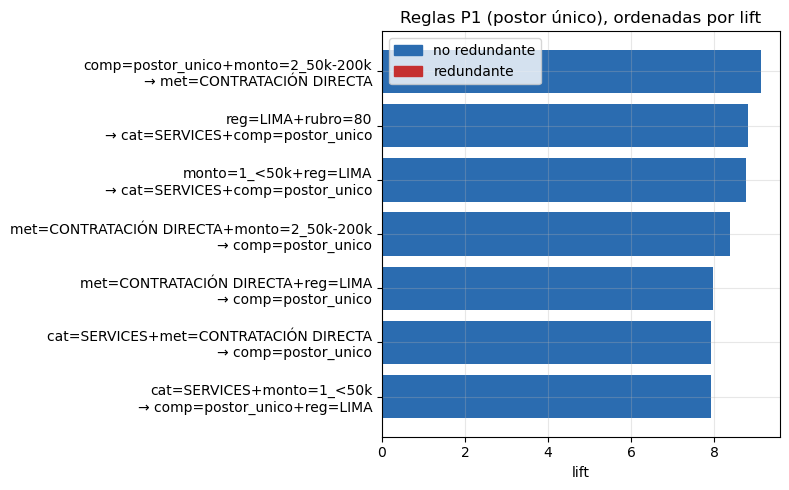

In [6]:
grupo_p1 = seleccion.iloc[:7]
etiqueta_p1 = (grupo_p1["antecedente"].apply(lambda a: "+".join(a))
               + "\n→ " + grupo_p1["consecuente"].apply(lambda c: "+".join(c)))

orden_p1 = grupo_p1["lift"].sort_values().index
y_pos = range(len(orden_p1))
colores_p1 = grupo_p1.loc[orden_p1, "redundante"].map({True: "#c53030", False: "#2b6cb0"})

plt.figure(figsize=(8, 5))
plt.barh(y_pos, grupo_p1.loc[orden_p1, "lift"], color=colores_p1)
plt.yticks(list(y_pos), etiqueta_p1[orden_p1])
plt.xlabel("lift"); plt.title("Reglas P1 (postor único), ordenadas por lift")
plt.legend(handles=[mpatches.Patch(color="#2b6cb0", label="no redundante"),
                     mpatches.Patch(color="#c53030", label="redundante")],
           loc="upper left")
mostrar_fig("lift_p1")

#### b. Lift - Demás

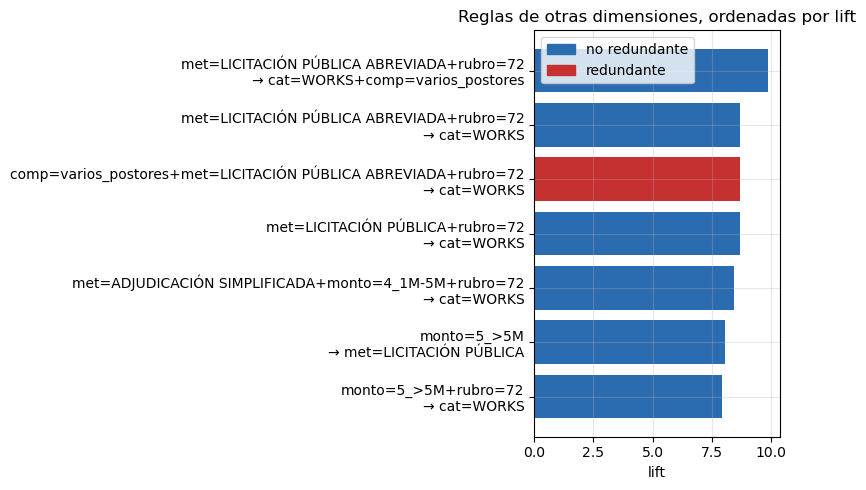

In [7]:
grupo_otras = seleccion.iloc[7:]
etiqueta_otras = (grupo_otras["antecedente"].apply(lambda a: "+".join(a))
                   + "\n→ " + grupo_otras["consecuente"].apply(lambda c: "+".join(c)))

orden_otras = grupo_otras["lift"].sort_values().index
y_pos = range(len(orden_otras))
colores_otras = grupo_otras.loc[orden_otras, "redundante"].map({True: "#c53030", False: "#2b6cb0"})

plt.figure(figsize=(8, 5))
plt.barh(y_pos, grupo_otras.loc[orden_otras, "lift"], color=colores_otras)
plt.yticks(list(y_pos), etiqueta_otras[orden_otras])
plt.xlabel("lift"); plt.title("Reglas de otras dimensiones, ordenadas por lift")
plt.legend(handles=[mpatches.Patch(color="#2b6cb0", label="no redundante"),
                     mpatches.Patch(color="#c53030", label="redundante")],
           loc="upper left")
mostrar_fig("lift_otras")

- De 496 reglas totales, solo 36 (7.3%) involucran `comp=postor_unico`

- Se tienen 14 seleccionadas (7 de P1 + 7 de otras dimensiones)

- 8 de las 14 aparecen en el subconjunto Apriori-Q4 (`estable_en_q4=True`)

- Todas las de `rubro=72`→`cat=WORKS` y la de `monto=5_>5M`→`met=LICITACIÓN PÚBLICA` son estables

- De 7 de P1, 2 se repiten en Q4 (las que combinan `met=CONTRATACIÓN DIRECTA` con región o categoría)

- Solo 1 de las 14 es redundante: la versión de la regla de `rubro=72` con `comp=varios_postores` 

### 3. Interpretación

Se interpretan las top reglas obtenidas

#### a. Postor único

La regla — `{met=CONTRATACIÓN DIRECTA} → {comp=postor_unico}`, confianza 86.6% no entra en el top, pero se usa para validar

**1. `{comp=postor_unico, monto=2_50k-200k} → {met=CONTRATACIÓN DIRECTA}`** 

- Confianza 53.1%, lift 9.1
- Dirección inversa: dado que un proceso ya es de postor único y de monto medio, más de la mitad
  termina siendo Contratación Directa
- Lift tan alto porque Contratación Directa es poco frecuente en general (5.8% de soporte)

**2. `{reg=LIMA, rubro=80} → {cat=SERVICES, comp=postor_unico}`** 

- Confianza 69.4%, lift 8.8, no estable en Q4
- `rubro=80` ("servicios de gestión/profesionales") en Lima casi siempre es `cat=SERVICES`
- 69.4% de esos procesos tienen un solo postor — geografía+rubro con alta concentración de baja competencia

**3. `{monto=1_<50k, reg=LIMA} → {cat=SERVICES, comp=postor_unico}`**

- Confianza 68.9%, lift 8.8, no estable en Q4
- Extiende el hallazgo de tramo bajo (57.3% de postor único en `1_<50k`) agregando región
- En Lima específicamente, los montos chicos en servicios concentran más baja competencia que el promedio nacional del tramo

**4. `{met=CONTRATACIÓN DIRECTA, monto=2_50k-200k} → {comp=postor_unico}`**

- Confianza 93.6%, lift 8.4, interés 0.824, no estable en Q4
- Combinar método + tramo de monto sube la confianza muy por encima del método
- Se logra concentran más al cruzar dimensiones, exactamente lo que Apriori/FP-Growth debe

**5. `{met=CONTRATACIÓN DIRECTA, reg=LIMA} → {comp=postor_unico}`**

- Confianza 89.0%, lift 8.0, estable en Q4
- Contratación Directa en Lima específicamente es aún más propensa a postor único que Contratación Directa 
- Refuerza el hallazgo de Lima como región de riesgo

**6. `{cat=SERVICES, met=CONTRATACIÓN DIRECTA} → {comp=postor_unico}`**

- Confianza 88.6%, lift 7.9, estable en Q4
- Contratación Directa en servicios también sube por encima del método solo

**7. `{cat=SERVICES, monto=1_<50k} → {comp=postor_unico, reg=LIMA}`**

- Confianza 60.1%, lift 7.9, no estable en Q4
- Servicios de monto bajo predicen a la vez postor único y Lima como región

#### b. Demás

Se usa como informacion adicional y util para el análisis, y para contrastar las anteriores

**8. `{met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS, comp=varios_postores}`** 

- Confianza 93.5%, lift 9.9, estable en Q4
- Un método competitivo + rubro de obras predice **varios postores**, no uno solo 
- Métodos competitivos funcionan como deberían cuando se trata de obras


**9. `{comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS}`**

- Confianza 100%, lift 8.70, marcada `redundante=True`
- Agregar `comp=varios_postores` al antecedente no mejora una confianza que ya era perfecta en la versión más simple (regla 10)

**10. `{met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS}`** 

- Confianza 100%, estable en Q4
- `rubro=72` mapea de forma casi determinista a `cat=WORKS` en el estándar UNSPSC

**11. `{met=LICITACIÓN PÚBLICA, rubro=72} → {cat=WORKS}`** 

- Confianza 99.98%, lift 8.70, estable en Q4
- Ahora con la variante "no abreviada" del método — refuerza `rubro=72`→`cat=WORKS`

**12. `{met=ADJUDICACIÓN SIMPLIFICADA, monto=4_1M-5M, rubro=72} → {cat=WORKS}`**

- Confianza 96.9%, lift 8.43, no estable en Q4
- confirma que la regla `rubro=72→WORKS` es robusta a través de métodos y montos

**13. `{monto=5_>5M} → {met=LICITACIÓN PÚBLICA}`** 

- Confianza 50.2%, lift 8.07, estable en Q4
- Los procesos de monto muy alto (>5M) tienden a usar Licitación Pública 
- Método que la ley de contrataciones exige para los montos mayores

**14. `{monto=5_>5M, rubro=72} → {cat=WORKS}`** 

- Confianza 91.3%, lift 7.95, estable en Q4
- Refuerza las reglas 10-11 (`rubro=72`→`cat=WORKS`)
- Muestra además que los montos más grandes del dataset se concentran en obras

### 4. Sensibilidad a umbrales

Se evalúa la sensibilidad de las reglas al variar `MIN_SUPPORT` y `MIN_CONFIANZA`

In [8]:
UMBRALES_SOPORTE = [0.02, 0.03, 0.05, 0.07, 0.10]
UMBRALES_CONFIANZA = [0.5, 0.6, 0.7, 0.8, 0.9]

es_ancla = (reglas_fpg_full["antecedente"].apply(lambda a: list(a) == ["met=CONTRATACIÓN DIRECTA"])
            & reglas_fpg_full["consecuente"].apply(lambda c: list(c) == ["comp=postor_unico"]))
reglas_eval = pd.concat([seleccion.assign(grupo=["p1"] * len(grupo_p1) + ["otras"] * len(grupo_otras)),
                         reglas_fpg_full[es_ancla].assign(grupo="ancla")], ignore_index=True)

def sobreviven(grupo, s, c):
    g = reglas_eval[reglas_eval["grupo"] == grupo]
    return int(((g["soporte"] >= s) & (g["confianza"] >= c)).sum())

supervivencia = pd.DataFrame([{"min_soporte": s, "min_confianza": c,
                               **{g: sobreviven(g, s, c) for g in ["p1", "otras", "ancla"]}}
                              for s in UMBRALES_SOPORTE for c in UMBRALES_CONFIANZA])
supervivencia["seleccionadas"] = supervivencia["p1"] + supervivencia["otras"]

supervivencia.pivot(index="min_soporte", columns="min_confianza", values="seleccionadas")

min_confianza,0.5,0.6,0.7,0.8,0.9
min_soporte,,,,,
0.02,14,12,9,9,7
0.03,1,1,1,1,0
0.05,0,0,0,0,0
0.07,0,0,0,0,0
0.10,0,0,0,0,0


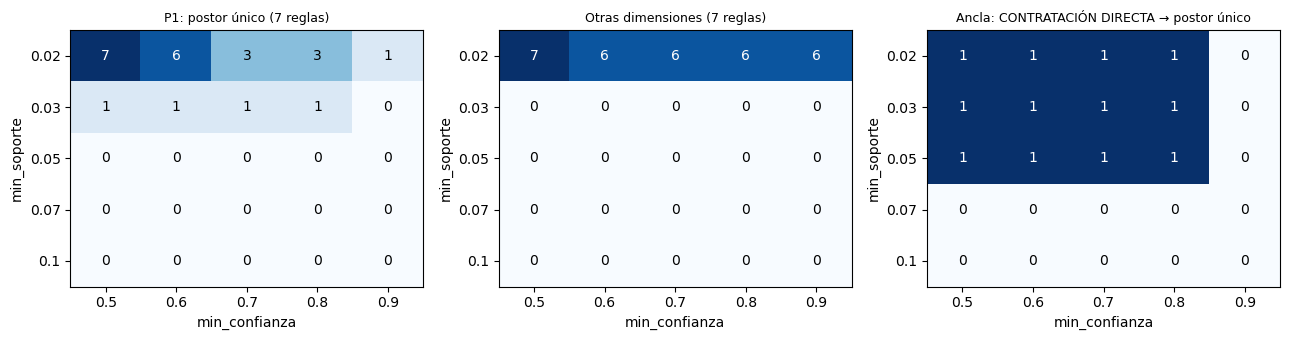

,grupo,antecedente,consecuente,soporte,confianza,lift
14,ancla,[met=CONTRATACIÓN DIRECTA],[comp=postor_unico],0.050,0.866,7.750
5,p1,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.032,0.886,7.923
1,p1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.029,0.694,8.815
4,p1,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.026,0.890,7.958
9,otras,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.025,1.000,8.701
13,otras,"[monto=5_>5M, rubro=72]",[cat=WORKS],0.024,0.913,7.948
7,otras,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.024,0.935,9.900
8,otras,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.024,1.000,8.701
2,p1,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.024,0.689,8.755
6,p1,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.024,0.601,7.920


In [9]:
grupos = [("p1", "P1: postor único (7 reglas)"), ("otras", "Otras dimensiones (7 reglas)"),
          ("ancla", "Ancla: CONTRATACIÓN DIRECTA → postor único")]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a_, (g, titulo) in zip(ax, grupos):
    m = supervivencia.pivot(index="min_soporte", columns="min_confianza", values=g)
    vmax = int((reglas_eval["grupo"] == g).sum())
    a_.imshow(m.values, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            a_.text(j, i, m.values[i, j], ha="center", va="center", color="white" if m.values[i, j] > vmax / 2 else "black")
    a_.set_xticks(range(m.shape[1]), m.columns); a_.set_yticks(range(m.shape[0]), m.index)
    a_.set_xlabel("min_confianza"); a_.set_ylabel("min_soporte"); a_.set_title(titulo, fontsize=9); a_.grid(False)
mostrar_fig("supervivencia_umbrales")

reglas_eval[["grupo", "antecedente", "consecuente", "soporte", "confianza", "lift"]].sort_values("soporte", ascending=False).round(3)

- El soporte es el umbral crítico: las reglas tienen soporte entre 2.1% y 3.2%.

- Con 0.03 solo sobrevive `{cat=SERVICES, met=CONTRATACIÓN DIRECTA} → {comp=postor_unico}` (3.2%)

- La confianza pesa menos: con 0.9 siguen 7 de 14; 6 de `rubro=72` (obras, confianza 0.91-1.0) y 1 con postor único

- En postor único, con confianza 0.7 quedan 3, todas con `met=CONTRATACIÓN DIRECTA`

- Con 0.9 solo `{met=CONTRATACIÓN DIRECTA, monto=2_50k-200k} → {comp=postor_unico}` (93.6%)

- La regla ancla (soporte 5.0%, confianza 86.6%) sobrevive hasta `min_soporte=0.05` y `min_confianza=0.8`

- Los hallazgos dependen de mantener un soporte bajo (2%)

---
### 5. Síntesis

In [10]:
seleccion[["antecedente", "consecuente", "soporte", "confianza", "lift", "interes", "redundante"]]

,antecedente,consecuente,soporte,confianza,lift,interes,redundante
0,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.022954,0.530980,9.121065,0.472766,False
1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.028628,0.693888,8.814776,0.615169,False
2,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.023729,0.689193,8.755127,0.610474,False
3,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.022954,0.935891,8.371007,0.824089,False
4,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025950,0.889712,7.957967,0.777911,False
5,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031875,0.885761,7.922629,0.773960,False
6,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.023729,0.600880,7.920230,0.525014,False
7,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.023839,0.935318,9.900495,0.840846,False
8,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.023839,1.000000,8.700690,0.885067,True
9,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.025488,1.000000,8.700690,0.885067,False


- Se confirma que `metodo_detalle`, `tramo_monto` y `region` por separado marcan un patrón de baja competencia

- Combinados en pares (método+monto, método+región, método+categoría) la confianza sube por encima del método solo

- Se dividio la selección en dos mitades iguales: 7 reglas con postor unico (competencia) y 7 de otras dimensiones

- La regla 8 (método competitivo + obras → varios postores) es un buen contraste. Se confirma que cuando el método realmente exige competencia, el patrón se invierte

- Las reglas 9-12 y 14 (`rubro=72`→`cat=WORKS` bajo distintos métodos y montos) no aportan a postor único pero sí confirman la consistencia de la codificación UNSPSC

- La regla 13 (monto muy alto → Licitación Pública) refleja una exigencia normativa, no un patrón de riesgo

### 6. Escritura de resultados

- Se guardan las 14 reglas y la tabla de supervivencia en `temp/d_analisis/tablas/` y `temp/d_analisis/web/`

In [11]:
reglas_seleccionadas = seleccion.assign(
    antecedente=seleccion["antecedente"].apply(list),
    consecuente=seleccion["consecuente"].apply(list),
    grupo=["p1"] * len(grupo_p1) + ["otras"] * len(grupo_otras))

escritos = {"seleccion": guardar_tabla(reglas_seleccionadas, "seleccion"),
            "supervivencia": guardar_tabla(supervivencia, "supervivencia")}
print(f"Escrito en temp/d_analisis/: {', '.join(escritos)}")

Escrito en temp/d_analisis/: seleccion, supervivencia


#### a. Verificación

In [12]:
assert escritos["seleccion"] == 14, f"esperaba 14 reglas, escribí {escritos['seleccion']}"

for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json)" + (f" | {len(figs)} figuras: {', '.join(figs)}" if figs else ""))

OK: 2 tablas (parquet + json) | 3 figuras: lift_otras, lift_p1, supervivencia_umbrales


---
### 7. Cerrar sesión

In [13]:
spark.stop()